# Show-Attend-and-Tell GRU for temporal AIT prediction from an observed pre-response state

## Main idea

This notebook predicts the temporal AIT population response to a static image
with frozen vision-backbone representations and a recurrent soft-attention
decoder. The decoder has one recurrent layer and no temporal embeddings.

It is identical to `GRU_attn_model_dev.ipynb` except for one extra input: the
first `cfg.n_early_bins` bins of the recorded response (5 bins = 0--50 ms at
100 Hz). AIT latency is well after 50 ms, so these bins carry no stimulus drive
yet; they carry the state the network was in before the response. They enter
where a state belongs, at the recurrent initial condition `h_0`, and are removed
from the targets, so the model is only scored on the bins it does not observe
(50--300 ms by default).

At each neural time bin, the previous hidden state attends over every embedding
coordinate in every selected backbone layer. The attended context updates one
shared `GRUCell`, and one shared linear readout maps the new state to the neural
population response:

```text
Static image
    |
    v
Frozen backbone layer features X [B, L, E]
    |
    +------------------------------+
    |                              |
    v                              |
h_0 = tanh(W [mean layer,          |
          early code])             |
      early code = GELU(W_e norm(r_0-50ms))
    |                              |
    v                              |
h_(t-1) -> feature attention ------+
    |          alpha_t [B, L, E]
    v
Attended context c_t
    |
    v
One shared GRUCell: h_t = GRU(c_t, h_(t-1))
    |
    v
One shared neural readout -> y_t [B, neurons]
```

The model uses the recurrent state itself as the attention query. There is no
learned time table, positional code, time-specific prediction head, or temporal
input. Consequently, differences among output bins can only arise from the
evolving recurrent state and its changing feature attention.

## Early-response initial state

For each presentation, the observed early bins `r [B, n_early, neurons]` are
flattened, layer-normalized, and projected to an `early_dim` code by the existing
`EarlyResponseEncoder`. The parent's initial-state map is widened to read the
mean normalized image layer concatenated with that code. Nothing else changes:
attention, `GRUCell`, readout, loss, and evaluation are those of the baseline.

**Caveat on the scores.** The early bins and the target bins of one sample come
from the same trial (raster) or the same repetition average (natraster), so any
noise they share can be tracked by the decoder and raises MSE and stim_r without
adding image information. On TVSD this gain reversed once predictions and
targets were averaged over disjoint repetition halves. With repeated rasters the
notebook therefore also reports the disjoint-half stim_r; for natraster-only data
(e.g. Paul) that check is unavailable and the gain over the image-only notebook
must be read with this in mind. The concatenated ridge is shown both image-only
and with the same early bins appended, which is the fair linear control.

## Optional noise pseudo-layer

With `cfg.use_noise_layer=True`, attention also ranges over one extra item, as
in `NoiseLayerBaselineModel`: a vector drawn uniformly on the sphere for every
image and forward pass, scaled to the mean norm of the normalized real layers
when `cfg.match_noise_norm=True`. It carries no stimulus information, so
attention mass spent on it is wasted prediction budget, which regularizes
peaked reads of any single real layer. It does not enter `h_0`. With
`cfg.noise_in_eval=True` the decoder stays stochastic during validation;
otherwise the noise item is a zero vector outside training. The layer-attention
panel then shows it as `__gaussian_sphere_noise__`.

## Optional temporal query embeddings

By default the recurrent state is the only time-varying attention query. With
`cfg.use_temporal_embeddings=True`, a learned embedding per predicted bin is
added to it, `q_t = W_h h_(t-1) + e_t`, so the attention schedule can change
over time even when the state settles. Differences among bins are then no
longer purely state-driven: part of the schedule is a learned clock.

## Attention

For each image, layer-feature coordinate `(l, e)` has a learned key direction
`k_le`. Its normalized backbone activation `x_ble` modulates the score produced by
the preceding state:

$$
s_{btle} = x_{ble}\,\frac{(W_h h_{b,t-1})^\top k_{le}}{\sqrt{d_a}},
\qquad
\alpha_{bt} = \operatorname{softmax}_{l,e}(s_{bt}).
$$

The softmax is joint over all `L * E` coordinates. The selected feature vector
is scaled by `L * E` before projection, so uniform initial attention preserves
the normalized feature magnitude. The final diagnostic matches the noisy baseline: feature weights are averaged
within each layer and renormalized over layers before plotting.

## Data and optimization

The data loading, image-identity train/validation split, frozen backbone feature
extraction, and concatenated-feature ridge reference match the baseline
notebook. When `cfg.use_reliability_weighted_loss=True`, split-half reliability
is converted to mean-one softmax weights using `cfg.temperature`; smaller values
concentrate the loss on fewer, more reliable time--neuron cells. Repeated
presentations of the same image remain in one partition, and reliability is
estimated from training image identities only. With the switch off, repeated
raster data are not loaded and exact uniform weights recover ordinary MSE,
which supports natraster-only recordings such as Paul.

The aligned weighted loss is

$$
\mathcal{L}=\frac{\sum_{t,n}w_{tn}
\left[\frac{1}{B}\sum_b(\hat y_{btn}-y_{btn})^2\right]}
{\sum_{t,n}w_{tn}}.
$$

This is a recurrent decoder of static visual features; it does not receive a
video. Attention identifies which pooled embedding coordinates are emphasized
as the latent neural state evolves, but it should not be interpreted as a
causal measure of feature importance.

In [1]:
import importlib
import os
import sys
from dataclasses import dataclass, field
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
import torch
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from transformers import AutoImageProcessor

# Locate the repository whether Jupyter starts in the project root or scripts folder.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]

# Put this repository first so another project's package cannot shadow it.
project_src_path = str((PROJECT_ROOT / "python_scripts" / "src").resolve())
useful_stuff_path = str(Path(paths["useful_stuff_path"]).resolve())
for source_path in (useful_stuff_path, project_src_path):
    while source_path in sys.path:
        sys.path.remove(source_path)
    # end while source path is already registered
    sys.path.insert(0, source_path)
# end for source path

# Reimport the development loader even if an older copy is kernel-cached.
sys.modules.pop("project_specific_utils.dataloader", None)
sys.modules.pop("project_specific_utils", None)
import project_specific_utils.dataloader as neural_dataloader
expected_dataloader_path = (
    Path(project_src_path) / "project_specific_utils" / "dataloader.py"
).resolve()
loaded_dataloader_path = Path(neural_dataloader.__file__).resolve()
if loaded_dataloader_path != expected_dataloader_path:
    raise ImportError(
        f"Expected neural loader {expected_dataloader_path}, loaded "
        f"{loaded_dataloader_path}."
    )
# end if a different project's loader was imported

# from II_analyses.static_encoding import (
#     compute_static_prediction_II,
#     fit_static_projection,
# )
from project_specific_utils.dataloader import (
    EarlyResponseInputDataset,
    apply_neural_preprocessing,
    fit_neural_preprocessing,
    load_img_natraster,
    load_img_raster,
    make_neural_input_loader,
    map_image_order_from_ann_to_monkey,
    map_trial_image_order_to_ann,
)
from IT_recap.hf_feature_extraction import (
    ProcessorTransform,
    is_valid_image_file,
    load_hf_layer_features,
)
# Reload development helpers when this cell is rerun in Jupyter.
import IT_recap.neural_prediction_training as neural_prediction_training
neural_prediction_training = importlib.reload(neural_prediction_training)
from IT_recap.neural_prediction_training import (
    aggregate_attention_by_layer,
    collect_image_level_predictions,
    collect_concatenated_layer_regression_data,
    collect_neural_predictions,
    crossvalidated_neural_response_mse,
    disjoint_half_stimulus_correlation,
    mean_stimulus_correlation,
    minimum_repetition_test_step,
    minimum_repetition_weighted_mse,
    neural_activity_weighted_mse_loss,
    plot_mean_channel_reconstruction,
    split_half_reliability,
    test_step,
    training_step,
)
from IT_recap.dynamic_drsa import (
    average_time_series_by_image,
    collect_gru_time_series,
    drsa_from_prepared,
    off_diagonal_limit,
    plot_drsa_matrix,
    prepared_rdm_time_series,
    rdm_split_half_reliability,
    time_axis_ms,
)
from IT_recap.tvsd_consistency import (
    consistency_weights,
    describe_weights,
    temperature_label,
)
from model_classes.early_response_models import (
    EarlyResponseShowAttendTellGRUModel,
)
from useful_stuff.general_utils.regression import linear_encoding
from useful_stuff.image_processing.computational_models import imgANN

In [2]:
@dataclass
class Cfg:
    # Neural recording and image-set parameters.
    # Paul natraster-only example: source="natraster", monkey="paul",
    # date="230204", folder="fewer_occlusion", and
    # use_reliability_weighted_loss=False. Use input_mode="images"
    # unless matching cached backbone activations have been extracted.
    neural_data_source: str = "natraster"  # "raster" or "natraster"
    monkey_name: str = "paul" #"three0"
    date: str = "230204" #"250313"
    brain_area: str = "AIT"
    folder_name: str = "fewer_occlusion" #"talia_20each_tizi"
    raster_file: str = "rasters_three0_250313to21.mat" # None #"paul_nat" #
    raster_key: str = "rasters"
    raster_image_names_file: str = "allimages_three0_250313to21.mat"
    raster_image_names_key: str = "allimages"
    original_fs: int = 1000
    new_fs: int = 100
    time_start_ms: float = 0
    time_end_ms: float = 300.0
    # The first n_early_bins of the window are model input, not targets:
    # 5 bins at new_fs=100 Hz observe 0-50 ms, before the AIT response.
    n_early_bins: int = 5
    raster_chunk_size: int = 512
    # Optional target preprocessing; statistics use training samples only.
    center_neural_features: bool = True
    robust_minmax_neurons: bool = False
    robust_percentile_range: tuple[float, float] = (1.0, 99.0)
    clip_robust_minmax: bool = True
    # False uses exact uniform weights and needs no repeated raster.
    use_reliability_weighted_loss: bool = False #True
    self_consistency_resamples: int = 40
    neural_response_ceiling_resamples: int = 200
    neural_response_ceiling_evaluation_fraction: float = 0.5
    # Softmax temperature over time-neuron reliability scores.
    temperature: float = 0.5
    # pca_comp = 100
    # Static model-feature parameters.
    model_name: str = "dino_v3_l" #"ijepa_vith14_1k"
    model_source: str = "facebook/dinov3-vitl16-pretrain-lvd1689m"
    img_size: int = 224
    use_fast_processor: bool = True
    pkg = "hf"
    layer_names: list[str] = field(default_factory=lambda: [
        "layer.3.mlp.down_proj",
        "layer.13.mlp.down_proj",
        "layer.20.mlp.down_proj",
        # "encoder.layer.4.output.dense",
        # "encoder.layer.17.output.dense",
        # "encoder.layer.27.output.dense",
    ])
    pooling: str = "mean"
    trust_remote_code = True
    attn_implementation = "sdpa"
    # Use "images" if cached backbone features do not exist for folder_name.
    training_input_mode: str = "activations"  #"images" # "images" or "activations"

    batch_size = 256
    validation_fraction: float = 0.2
    random_seed: int = 0
    epochs: int = 1000
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    # One GRUCell is unrolled over all neural target bins.
    hidden_dim: int = 128
    attention_dim: int = 64
    dropout: float = 0.5
    # Width of the early-response code that joins the image in h_0.
    early_dim: int = 64
    early_dropout: float = 0.0
    # Optional sphere-noise pseudo-layer that competes for attention.
    use_noise_layer: bool = True
    match_noise_norm: bool = True
    noise_in_eval: bool = True
    # Learned per-bin embedding added to the attention query.
    use_temporal_embeddings: bool = True
    # Dynamic-RSA visualization parameters.
    drsa_rdm_metric: str = "euclidean"
    drsa_rsa_metric: str = "spearman"
    drsa_reliability_resamples: int = 10
    reconstruction_plot_interval: int = 50
    reconstruction_sample_index: int = 10
    
# EOC


cfg = Cfg()
cfg

Cfg(neural_data_source='natraster', monkey_name='paul', date='230204', brain_area='AIT', folder_name='fewer_occlusion', raster_file='rasters_three0_250313to21.mat', raster_key='rasters', raster_image_names_file='allimages_three0_250313to21.mat', raster_image_names_key='allimages', original_fs=1000, new_fs=100, time_start_ms=0, time_end_ms=300.0, n_early_bins=5, raster_chunk_size=512, center_neural_features=True, robust_minmax_neurons=False, robust_percentile_range=(1.0, 99.0), clip_robust_minmax=True, use_reliability_weighted_loss=False, self_consistency_resamples=40, neural_response_ceiling_resamples=200, neural_response_ceiling_evaluation_fraction=0.5, temperature=0.5, model_name='dino_v3_l', model_source='facebook/dinov3-vitl16-pretrain-lvd1689m', img_size=224, use_fast_processor=True, layer_names=['layer.3.mlp.down_proj', 'layer.13.mlp.down_proj', 'layer.20.mlp.down_proj'], pooling='mean', training_input_mode='activations', validation_fraction=0.2, random_seed=0, epochs=1000, learn

## Load and align the static spaces

The neural data are shaped `(neurons, timepoints, samples)`. With `neural_data_source="raster"`, samples are repeated single trials and their explicit presentation names determine the image mapping. With `neural_data_source="natraster"`, samples are unique-image averages and the ordering follows `run_static_dRSA.py`: `load_img_natraster` plus `map_image_order_from_ann_to_monkey`. Cached backbone features remain in ImageFolder source order.

In [3]:
# Cached activations need only ImageFolder's file ordering. Load the Hugging
# Face processor only when raw images will actually enter the backbone.
image_processor = None
dataset_transform = None
if cfg.training_input_mode == "images":
    image_processor = AutoImageProcessor.from_pretrained(
        cfg.model_source,
        use_fast=cfg.use_fast_processor,
    )
    dataset_transform = ProcessorTransform(image_processor)
# end if online image preprocessing is needed

dataset_path = Path(paths["livingstone_lab"]) / "Stimuli" / cfg.folder_name
dataset = ImageFolder(
    root=dataset_path,
    transform=dataset_transform,
    is_valid_file=is_valid_image_file,
    allow_empty=True,
)

if cfg.training_input_mode == "images":
    # Fail early if the processor and configured model size disagree.
    sample_image, _ = dataset[0]
    sample_shape = tuple(sample_image.shape[-2:])
    if sample_shape != (cfg.img_size, cfg.img_size):
        raise ValueError(
            f"Processor returned {sample_shape}, expected "
            f"{(cfg.img_size, cfg.img_size)}."
        )
    # end if processor output size differs from model input size
# end if raw images require processor validation

# Align neural samples to ImageFolder following the appropriate source format.
if cfg.neural_data_source == "raster":
    raster, neural_image_names = load_img_raster(
        paths=paths,
        monkey_name=cfg.monkey_name,
        raster_file=cfg.raster_file,
        image_names_file=cfg.raster_image_names_file,
        raster_key=cfg.raster_key,
        image_names_key=cfg.raster_image_names_key,
        original_fs=cfg.original_fs,
        new_fs=cfg.new_fs,
        time_start_ms=cfg.time_start_ms,
        time_end_ms=cfg.time_end_ms,
        brain_area=cfg.brain_area,
        chunk_size=cfg.raster_chunk_size,
    )
    neural_image_indices = map_trial_image_order_to_ann(
        neural_image_names,
        dataset,
    )
elif cfg.neural_data_source == "natraster":
    # Match run_static_dRSA.py: natraster rows follow sorted unique names.
    raster = load_img_natraster(
        paths=paths,
        monkey_name=cfg.monkey_name,
        date=cfg.date,
        original_fs=cfg.original_fs,
        new_fs=cfg.new_fs,
        time_start_ms=cfg.time_start_ms,
        time_end_ms=cfg.time_end_ms,
        brain_area=cfg.brain_area,
    )
    neural_image_indices = np.asarray(
        map_image_order_from_ann_to_monkey(
            paths,
            cfg.monkey_name,
            cfg.date,
            dataset,
        ),
        dtype=int,
    )
else:
    raise ValueError(
        "neural_data_source must be either 'raster' or 'natraster'."
    )
# end if repeated raster or averaged natraster is requested

raw_raster_array = raster.get_array()

if raw_raster_array.ndim != 3:
    raise ValueError(
        "Expected neural data with shape (neurons, timepoints, trials), "
        f"received {raw_raster_array.shape}."
    )
# end if raw_raster_array.ndim != 3

if len(neural_image_indices) != raw_raster_array.shape[2]:
    raise ValueError(
        f"Found {len(neural_image_indices)} aligned images but "
        f"{raw_raster_array.shape[2]} neural samples."
    )
# end if neural data and image ordering differ

# Split image identities before fitting target preprocessing so validation
# responses never contribute to centering or robust min-max statistics.
if not 0.0 < cfg.validation_fraction < 1.0:
    raise ValueError("validation_fraction must be between zero and one.")
# end if validation fraction is invalid
unique_image_indices = np.unique(neural_image_indices)
n_validation_images = max(
    1,
    round(len(unique_image_indices) * cfg.validation_fraction),
)
if n_validation_images >= len(unique_image_indices):
    raise ValueError("The validation split leaves no training images.")
# end if training image split is empty
split_rng = np.random.default_rng(cfg.random_seed)
shuffled_image_indices = split_rng.permutation(unique_image_indices)
validation_image_ids = shuffled_image_indices[:n_validation_images]
is_validation_trial = np.isin(neural_image_indices, validation_image_ids)
training_trial_indices = np.flatnonzero(~is_validation_trial).tolist()
validation_trial_indices = np.flatnonzero(is_validation_trial).tolist()
validation_trial_image_indices = np.asarray(
    neural_image_indices[validation_trial_indices]
)

neural_preprocessing_stats = fit_neural_preprocessing(
    raw_raster_array,
    fitting_sample_indices=training_trial_indices,
    center_features=cfg.center_neural_features,
    robust_minmax_neurons=cfg.robust_minmax_neurons,
    robust_percentile_range=cfg.robust_percentile_range,
    clip_robust_minmax=cfg.clip_robust_minmax,
)
raster_array = apply_neural_preprocessing(
    raw_raster_array,
    neural_preprocessing_stats,
)

# Repeated targets are needed only for reliability weighting and its
# associated neural-response and dRSA ceiling diagnostics.
self_consistency_trial_targets = None
self_consistency_image_indices = None
if cfg.use_reliability_weighted_loss:
    if cfg.neural_data_source == "raster":
        raw_self_consistency_raster_array = raw_raster_array
        self_consistency_image_indices = neural_image_indices.copy()
    else:
        self_consistency_raster, self_consistency_image_names = (
            load_img_raster(
                paths=paths,
                monkey_name=cfg.monkey_name,
                raster_file=cfg.raster_file,
                image_names_file=cfg.raster_image_names_file,
                raster_key=cfg.raster_key,
                image_names_key=cfg.raster_image_names_key,
                original_fs=cfg.original_fs,
                new_fs=cfg.new_fs,
                time_start_ms=cfg.time_start_ms,
                time_end_ms=cfg.time_end_ms,
                brain_area=cfg.brain_area,
                chunk_size=cfg.raster_chunk_size,
            )
        )
        raw_self_consistency_raster_array = (
            self_consistency_raster.get_array()
        )
        self_consistency_image_indices = map_trial_image_order_to_ann(
            self_consistency_image_names,
            dataset,
        )
    # end if training targets already contain repeated trials

    if (
        raw_self_consistency_raster_array.shape[:2]
        != raw_raster_array.shape[:2]
    ):
        raise ValueError(
            "Repeated targets and training targets disagree in their "
            "[neurons, time] shape: "
            f"{raw_self_consistency_raster_array.shape[:2]} and "
            f"{raw_raster_array.shape[:2]}."
        )
    # end if reliability targets do not align with model outputs

    self_consistency_raster_array = apply_neural_preprocessing(
        raw_self_consistency_raster_array,
        neural_preprocessing_stats,
    )
    self_consistency_trial_targets = (
        self_consistency_raster_array.transpose(2, 1, 0)
    )
# end if reliability-weighted loss needs repeated targets

# The observed early bins are input only; every target, weight, and ceiling
# below covers the remaining [n_early_bins:] bins of the window.
n_timepoints_total = raster_array.shape[1]
if not 0 < cfg.n_early_bins < n_timepoints_total:
    raise ValueError(
        f"n_early_bins must lie in (0, {n_timepoints_total}), "
        f"got {cfg.n_early_bins}."
    )
# end if the early window leaves no target bins
n_target_timepoints = n_timepoints_total - cfg.n_early_bins
target_time_start_ms = cfg.time_start_ms + cfg.n_early_bins * 1000.0 / cfg.new_fs
if self_consistency_trial_targets is not None:
    # [trials, time, neurons] -> keep only the predicted bins.
    self_consistency_trial_targets = (
        self_consistency_trial_targets[:, cfg.n_early_bins:]
    )
# end if repeated targets must match the predicted window

# Cached backbone outputs are needed only when bypassing the frozen model.
precomputed_layer_features = None
if cfg.training_input_mode == "activations":
    precomputed_layer_features = load_hf_layer_features(
        output_dir=Path(paths["data_path"]) / "models",
        dataset_name=cfg.folder_name,
        model_name=cfg.model_name,
        img_size=cfg.img_size,
        layer_names=cfg.layer_names,
        pooling=cfg.pooling,
    )
    if precomputed_layer_features.shape[0] != len(dataset):
        raise ValueError(
            "Cached features and ImageFolder have different image counts: "
            f"{precomputed_layer_features.shape[0]} and {len(dataset)}."
        )
    # end if cached features and ImageFolder are misaligned
elif cfg.training_input_mode != "images":
    raise ValueError(
        "training_input_mode must be either 'images' or 'activations'."
    )
# end if cached features are requested

print(f"{cfg.neural_data_source} neural data: {raster_array.shape}")
print(
    f"early input: {cfg.n_early_bins} bins "
    f"{cfg.time_start_ms:.0f}-{target_time_start_ms:.0f} ms | "
    f"targets: {n_target_timepoints} bins "
    f"{target_time_start_ms:.0f}-{cfg.time_end_ms:.0f} ms"
)
print(
    "neural preprocessing: "
    f"center_features={cfg.center_neural_features}, "
    f"robust_minmax_neurons={cfg.robust_minmax_neurons}, "
    f"percentiles={cfg.robust_percentile_range}"
)
print(f"Aligned unique stimuli: {len(np.unique(neural_image_indices))}")
if self_consistency_trial_targets is None:
    print("Repeated raster: skipped; training uses ordinary MSE")
else:
    print(
        "Repeated trials for self-consistency: "
        f"{len(self_consistency_trial_targets)}"
    )
# end if repeated targets are unavailable
if precomputed_layer_features is not None:
    print(f"Cached backbone features: {precomputed_layer_features.shape}")
else:
    print("Training input: images (backbone runs online)")
# end if cached features were loaded


natraster neural data: (19, 30, 4377)
early input: 5 bins 0-50 ms | targets: 25 bins 50-300 ms
neural preprocessing: center_features=True, robust_minmax_neurons=False, percentiles=(1.0, 99.0)
Aligned unique stimuli: 4377
Repeated raster: skipped; training uses ordinary MSE
Cached backbone features: (4379, 3, 1024)


In [4]:
# NeuralInputDataset is implemented in project_specific_utils.dataloader.


In [5]:
# Cached-feature training does not instantiate the Hugging Face backbone.
if torch.cuda.is_available():
    model_device = torch.device("cuda")
elif torch.backends.mps.is_available():
    model_device = torch.device("mps")
else:
    model_device = torch.device("cpu")
# end if selecting the best available training device

ann = None
if cfg.training_input_mode == "images":
    ann = imgANN(
        model_name=cfg.model_name,
        pkg=cfg.pkg,
        img_size=cfg.img_size,
        pooling=cfg.pooling,
        dtype=torch.float32,
        attn_implementation=cfg.attn_implementation,
        repo_url=cfg.model_source,
        trust_remote_code=cfg.trust_remote_code,
        device=str(model_device),
    )

    # Layer paths must belong to the loaded repository.
    available_layer_names = set(dict(ann.model.named_modules()))
    missing_layer_names = [
        layer_name
        for layer_name in cfg.layer_names
        if layer_name not in available_layer_names
    ]
    if missing_layer_names:
        raise ValueError(
            f"Configured layers {missing_layer_names} are not present in "
            f"the model loaded from {cfg.model_source!r}. Keep model_name, "
            "model_source, and layer_names from one backbone preset."
        )
    # end if configured layers do not belong to the loaded backbone
else:
    print(
        f"cached-feature mode: skipping processor and backbone loading | "
        f"device {model_device}"
    )
# end if online image encoding is required

cached-feature mode: skipping processor and backbone loading | device mps


In [6]:
# Change cfg.training_input_mode to switch the training input source.
loader = make_neural_input_loader(
    input_mode=cfg.training_input_mode,
    image_dataset=dataset,
    activations=precomputed_layer_features,
    neural_activity=raster_array,
    image_indices=neural_image_indices,
    batch_size=cfg.batch_size,
    shuffle=True,
    pin_memory=model_device.type == "cuda",
)

# Split each full-window response into the observed early bins and the target:
# batches become (model_input, early_response [B, n_early, neurons],
# target [B, time - n_early, neurons]).
early_response_dataset = EarlyResponseInputDataset(
    loader.dataset,
    n_early_bins=cfg.n_early_bins,
)


In [7]:
# EarlyResponseShowAttendTellGRUModel is implemented in model_classes.early_response_models.


## Temperature-controlled self-consistency-weighted neural-activity loss

For every `(time, neuron)` target cell, repeated responses to each training
stimulus are split in half and averaged. The two stimulus-preference vectors
are correlated, averaged across resamples, and Spearman--Brown corrected. The
square root of this reliability is the stimulus-correlation ceiling
$r_{tn}\in[0,1]$ returned by `split_half_reliability`.

The new loss temperature converts these reliabilities into positive softmax
weights over all $C$ time--neuron cells:

$$
w_{tn}=C\,\frac{\exp(r_{tn}/\tau)}
{\sum_{t',n'}\exp(r_{t'n'}/\tau)}.
$$

The weights have mean one. A high temperature approaches ordinary MSE; a low
temperature concentrates optimization on the most reliable target cells. The
aligned weighted loss remains

$$
\mathcal{L}=\frac{\sum_{t,n}w_{tn}
\left[\frac{1}{B}\sum_b(\hat y_{btn}-y_{btn})^2\right]}
{\sum_{t,n}w_{tn}}.
$$

Reliability is estimated using training-image identities only. No temporal
shifting, averaging across bins, or validation-image preference information is
used to construct the weights. With `use_reliability_weighted_loss=False`,
the repeated-raster load and reliability estimate are skipped. Uniform weights
make this objective exactly ordinary MSE for natraster-only data such as Paul.

In [8]:
# neural_activity_weighted_mse_loss is implemented in IT_recap.neural_prediction_training.


# Training and online validation
## training (repeat for the whole training set -> 1 epoch)
1. Pass minibatch
2. compute loss
3. backpropagate
4. do the optimizer step
5. zero the gradient
6. accumulate the sample-weighted training loss

## testing (repeat for the whole validation set at every epoch)
1. switch the network to evaluation mode
2. compute the loss
3. accumulate the sample-weighted validation loss


In [9]:
# Training, validation, plotting, and ridge-data helpers are implemented in IT_recap.neural_prediction_training.


In [10]:
# Reuse the same seed for model initialization and the data split.
torch.manual_seed(cfg.random_seed)
m = EarlyResponseShowAttendTellGRUModel(
    ann,
    layers=cfg.layer_names,
    n_timepoints=n_target_timepoints,
    n_neurons=raster_array.shape[0],
    hidden_dim=cfg.hidden_dim,
    attention_dim=cfg.attention_dim,
    n_early_bins=cfg.n_early_bins,
    early_dim=cfg.early_dim,
    dropout=cfg.dropout,
    early_dropout=cfg.early_dropout,
    use_noise_layer=cfg.use_noise_layer,
    match_noise_norm=cfg.match_noise_norm,
    noise_in_eval=cfg.noise_in_eval,
    use_temporal_embeddings=cfg.use_temporal_embeddings,
    encoder_dim=(
        None
        if precomputed_layer_features is None
        else precomputed_layer_features.shape[-1]
    ),
).to(model_device)
m

EarlyResponseShowAttendTellGRUModel(
  (feature_input_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=False, bias=False)
  (hidden_query_projection): Linear(in_features=128, out_features=64, bias=False)
  (initial_state): Sequential(
    (0): Linear(in_features=1088, out_features=128, bias=True)
    (1): Tanh()
  )
  (context_projection): Linear(in_features=4096, out_features=128, bias=False)
  (context_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (recurrence): GRUCell(128, 128)
  (dropout): Dropout(p=0.5, inplace=False)
  (readout): Linear(in_features=128, out_features=19, bias=True)
  (early_encoder): EarlyResponseEncoder(
    (input_norm): LayerNorm((95,), eps=1e-05, elementwise_affine=False, bias=False)
    (projection): Linear(in_features=95, out_features=64, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
)

split: 3502 images / 3502 trials for training; 875 images / 875 trials for validation
reliability-weighted loss: off | uniform weights (25, 19) | ordinary MSE
concatenated-layer ridge | MSE 0.040709 | mean stim_r 0.3059
concatenated-layer ridge + early response | MSE 0.041013 | mean stim_r 0.3000
predict training mean | MSE 0.047029 | mean stim_r undefined (prediction is constant across images)
epoch 000/1000 | validation MSE 0.091914 | mean stim_r -0.0020


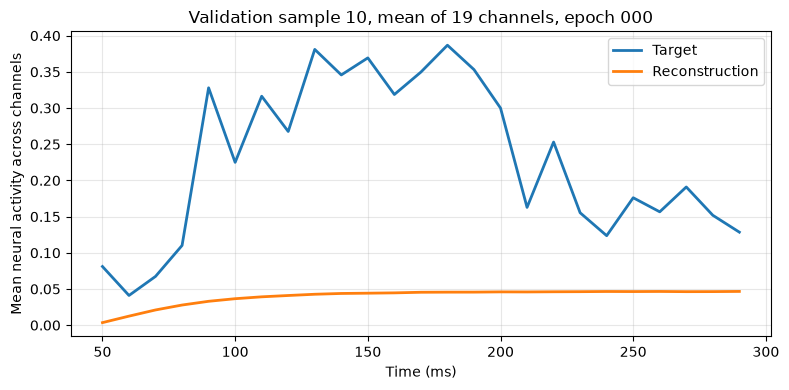

epoch 001/1000 | train MSE 0.121784 | validation MSE 0.048659 | train stim_r 0.1699 | validation stim_r 0.1761
epoch 002/1000 | train MSE 0.055624 | validation MSE 0.044941 | train stim_r 0.2132 | validation stim_r 0.2251
epoch 003/1000 | train MSE 0.047763 | validation MSE 0.043798 | train stim_r 0.2422 | validation stim_r 0.2486
epoch 004/1000 | train MSE 0.045499 | validation MSE 0.043108 | train stim_r 0.2661 | validation stim_r 0.2674
epoch 005/1000 | train MSE 0.044468 | validation MSE 0.042585 | train stim_r 0.2813 | validation stim_r 0.2803
epoch 006/1000 | train MSE 0.043789 | validation MSE 0.042239 | train stim_r 0.2967 | validation stim_r 0.2871
epoch 007/1000 | train MSE 0.043383 | validation MSE 0.041919 | train stim_r 0.3098 | validation stim_r 0.2925
epoch 008/1000 | train MSE 0.042898 | validation MSE 0.041712 | train stim_r 0.3175 | validation stim_r 0.2974
epoch 009/1000 | train MSE 0.042379 | validation MSE 0.041502 | train stim_r 0.3274 | validation stim_r 0.3005
e

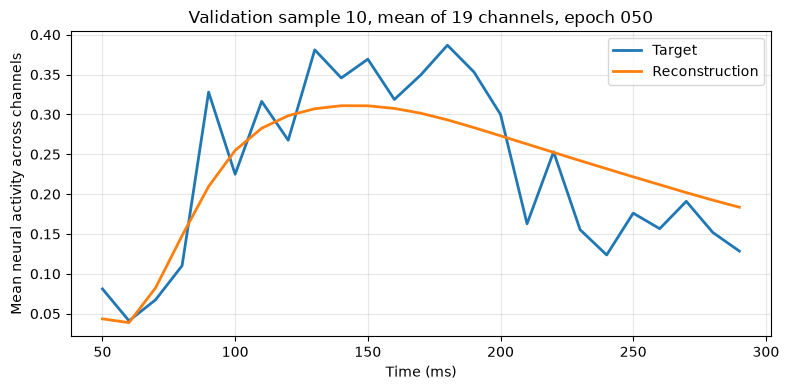

epoch 051/1000 | train MSE 0.036613 | validation MSE 0.041381 | train stim_r 0.4314 | validation stim_r 0.3133
epoch 052/1000 | train MSE 0.036596 | validation MSE 0.041507 | train stim_r 0.4324 | validation stim_r 0.3147
epoch 053/1000 | train MSE 0.036594 | validation MSE 0.041338 | train stim_r 0.4329 | validation stim_r 0.3154
epoch 054/1000 | train MSE 0.036473 | validation MSE 0.041466 | train stim_r 0.4347 | validation stim_r 0.3123
epoch 055/1000 | train MSE 0.036538 | validation MSE 0.041283 | train stim_r 0.4341 | validation stim_r 0.3165
epoch 056/1000 | train MSE 0.036447 | validation MSE 0.041509 | train stim_r 0.4354 | validation stim_r 0.3163
epoch 057/1000 | train MSE 0.036447 | validation MSE 0.041369 | train stim_r 0.4357 | validation stim_r 0.3129
epoch 058/1000 | train MSE 0.036444 | validation MSE 0.041279 | train stim_r 0.4364 | validation stim_r 0.3157
epoch 059/1000 | train MSE 0.036302 | validation MSE 0.041431 | train stim_r 0.4375 | validation stim_r 0.3141
e

KeyboardInterrupt: 

In [11]:
# Reuse the image-level split created before target preprocessing.
full_dataset = early_response_dataset
training_dataset = Subset(full_dataset, training_trial_indices)
validation_dataset = Subset(full_dataset, validation_trial_indices)

# Confirm that repeated presentations never cross the split boundary.
training_image_indices = set(
    full_dataset.image_indices[training_trial_indices].tolist()
)
validation_image_indices = set(validation_trial_image_indices.tolist())
if training_image_indices & validation_image_indices:
    raise RuntimeError("An image appears in both training and validation.")
# end if repeated images leaked across splits
print(
    f"split: {len(training_image_indices)} images / "
    f"{len(training_trial_indices)} trials for training; "
    f"{len(validation_image_indices)} images / "
    f"{len(validation_trial_indices)} trials for validation"
)

# Reliability weighting requires repeated trials. With the switch off,
# an all-ones map makes the shared weighted objective exactly plain MSE.
weight_shape = (n_target_timepoints, raster_array.shape[0])
self_consistency_reliability = None
neural_response_ceiling = None
if cfg.use_reliability_weighted_loss:
    if cfg.self_consistency_resamples <= 0:
        raise ValueError("self_consistency_resamples must be positive.")
    # end if no split-half resamples were requested

    # Only training identities define the per-cell reliability weights.
    self_consistency_training_mask = np.isin(
        self_consistency_image_indices,
        list(training_image_indices),
    )
    candidate_image_indices, candidate_repetition_counts = np.unique(
        self_consistency_image_indices[self_consistency_training_mask],
        return_counts=True,
    )
    eligible_image_indices = candidate_image_indices[
        candidate_repetition_counts >= 2
    ]
    if len(eligible_image_indices) < 2:
        raise ValueError(
            "Self-consistency requires at least two training images "
            "with at least two repetitions each."
        )
    # end if reliability cannot be estimated

    self_consistency_training_mask &= np.isin(
        self_consistency_image_indices,
        eligible_image_indices,
    )
    selected_self_consistency_image_indices = (
        self_consistency_image_indices[self_consistency_training_mask]
    )
    _, compact_self_consistency_image_ids = np.unique(
        selected_self_consistency_image_indices,
        return_inverse=True,
    )
    selected_self_consistency_targets = self_consistency_trial_targets[
        self_consistency_training_mask
    ]
    stimulus_preference_ceiling = split_half_reliability(
        selected_self_consistency_targets,
        compact_self_consistency_image_ids,
        n_images=len(eligible_image_indices),
        reducer="mean",
        n_resamples=cfg.self_consistency_resamples,
        seed=cfg.random_seed,
    )
    self_consistency_reliability = np.nan_to_num(
        stimulus_preference_ceiling,
        nan=0.0,
        posinf=1.0,
        neginf=0.0,
    ).astype(np.float32)
    self_consistency_weights = consistency_weights(
        self_consistency_reliability,
        temperature=cfg.temperature,
    ).astype(np.float32)
    weight_description = describe_weights(
        self_consistency_weights,
        self_consistency_reliability,
    )
    print(
        "self-consistency weights [time, neurons] "
        f"{self_consistency_weights.shape} | "
        f"temperature {temperature_label(cfg.temperature)} | "
        f"effective cells "
        f"{weight_description['n_effective_cells']:.1f}/"
        f"{self_consistency_weights.size} | "
        f"max/mean "
        f"{weight_description['weight_max_over_mean']:.3f}"
    )

    neural_ceiling_validation_mask = np.isin(
        self_consistency_image_indices,
        list(validation_image_indices),
    )
    neural_response_ceiling = crossvalidated_neural_response_mse(
        trial_targets=self_consistency_trial_targets[
            neural_ceiling_validation_mask
        ],
        image_ids=self_consistency_image_indices[
            neural_ceiling_validation_mask
        ],
        weights=self_consistency_weights,
        n_resamples=cfg.neural_response_ceiling_resamples,
        evaluation_fraction=(
            cfg.neural_response_ceiling_evaluation_fraction
        ),
        seed=cfg.random_seed,
    )
    print(
        "cross-validated neural-response MSE ceiling | "
        f"minimum {neural_response_ceiling['minimum_mse']:.6f} | "
        f"mean {neural_response_ceiling['mean_mse']:.6f} | "
        f"5--95% "
        f"[{neural_response_ceiling['percentile_05']:.6f}, "
        f"{neural_response_ceiling['percentile_95']:.6f}]"
    )
else:
    self_consistency_weights = np.ones(weight_shape, dtype=np.float32)
    print(
        "reliability-weighted loss: off | uniform weights "
        f"{self_consistency_weights.shape} | ordinary MSE"
    )
# end if reliability weighting is enabled

pin_memory = torch.device(m.device).type == "cuda"
training_generator = torch.Generator()
training_generator.manual_seed(cfg.random_seed)
training_loader = DataLoader(
    training_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    pin_memory=pin_memory,
    generator=training_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    pin_memory=pin_memory,
)
training_evaluation_loader = DataLoader(
    training_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    pin_memory=pin_memory,
)

# Repeated trials are averaged by image for correlation and RSA.
training_correlation_image_ids = None
validation_correlation_image_ids = None
if cfg.neural_data_source == "raster":
    training_correlation_image_ids = np.asarray(
        full_dataset.image_indices[training_trial_indices]
    )
    validation_correlation_image_ids = validation_trial_image_indices
# end if evaluation samples contain repeated image presentations

# Configure regression optimization over trainable parameters only.
optimizer = torch.optim.AdamW(
    m.get_trainable_parameters(),
    lr=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
)
self_consistency_weight_tensor = torch.as_tensor(
    self_consistency_weights,
    dtype=torch.float32,
    device=m.device,
)
cost_function = partial(
    neural_activity_weighted_mse_loss,
    weights=self_consistency_weight_tensor,
)
training_metric_label = (
    "reliability-weighted MSE"
    if cfg.use_reliability_weighted_loss
    else "MSE"
)
use_precomputed_features = full_dataset.input_mode == "activations"
if cfg.neural_data_source == "raster":
    validation_function = partial(
        minimum_repetition_test_step,
        image_ids=validation_trial_image_indices,
        weights=self_consistency_weights,
    )
    validation_metric_label = (
        "minimum-repetition reliability-weighted MSE"
        if cfg.use_reliability_weighted_loss
        else "minimum-repetition MSE"
    )
else:
    validation_function = partial(test_step, cost_function=cost_function)
    validation_metric_label = training_metric_label
# end if repeated raster validation needs image-wise minima
optimizer.zero_grad(set_to_none=True)

# Fit plain ridge on the same image-grouped split used by the neural model.
ridge_training_features, ridge_training_targets = (
    collect_concatenated_layer_regression_data(
        m,
        training_loader,
        use_precomputed_features,
        device=m.device,
    )
)
ridge_validation_features, ridge_validation_targets = (
    collect_concatenated_layer_regression_data(
        m,
        validation_loader,
        use_precomputed_features,
        device=m.device,
    )
)
ridge_encoding = linear_encoding(
    regression_type="ridge",
    cv_type="same",
)
ridge_encoding.fit(
    ridge_training_features,
    ridge_training_targets,
    transpose=False,
)
ridge_validation_predictions = ridge_encoding.predict(
    ridge_validation_features,
    transpose=False,
    transpose_output=False,
)
target_shape = (n_target_timepoints, raster_array.shape[0])
ridge_training_targets = ridge_training_targets.reshape(-1, *target_shape)
ridge_validation_targets = ridge_validation_targets.reshape(
    -1, *target_shape
)
ridge_validation_predictions = ridge_validation_predictions.reshape(
    -1, *target_shape
)
# The predict-mean baseline is estimated only from training trials.
training_mean_prediction = ridge_training_targets.mean(axis=0, keepdims=True)
mean_validation_predictions = np.broadcast_to(
    training_mean_prediction,
    ridge_validation_targets.shape,
)
if cfg.neural_data_source == "raster":
    ridge_validation_mse = minimum_repetition_weighted_mse(
        ridge_validation_predictions,
        ridge_validation_targets,
        validation_trial_image_indices,
        self_consistency_weights,
    )
    mean_validation_mse = minimum_repetition_weighted_mse(
        mean_validation_predictions,
        ridge_validation_targets,
        validation_trial_image_indices,
        self_consistency_weights,
    )
else:
    ridge_validation_cell_mse = np.mean(
        (ridge_validation_predictions - ridge_validation_targets) ** 2,
        axis=0,
    )
    mean_validation_cell_mse = np.mean(
        (mean_validation_predictions - ridge_validation_targets) ** 2,
        axis=0,
    )
    ridge_validation_mse = float(np.average(
        ridge_validation_cell_mse, weights=self_consistency_weights
    ))
    mean_validation_mse = float(np.average(
        mean_validation_cell_mse, weights=self_consistency_weights
    ))
# end if validation contains repeated raster trials

# Correlation and RSA compare one population response per validation image.
if cfg.neural_data_source == "raster":
    ridge_image_predictions, ridge_image_ids = average_time_series_by_image(
        ridge_validation_predictions, validation_trial_image_indices
    )
    mean_image_predictions, mean_image_ids = average_time_series_by_image(
        mean_validation_predictions, validation_trial_image_indices
    )
    validation_image_targets, target_image_ids = average_time_series_by_image(
        ridge_validation_targets, validation_trial_image_indices
    )
    if not (
        np.array_equal(ridge_image_ids, target_image_ids)
        and np.array_equal(mean_image_ids, target_image_ids)
    ):
        raise RuntimeError(
            "Regression predictions and targets use different images."
        )
    # end if image-averaged regression rows are misaligned
else:
    ridge_image_predictions = ridge_validation_predictions
    mean_image_predictions = mean_validation_predictions
    validation_image_targets = ridge_validation_targets
# end if regression arrays contain repeated presentations
ridge_validation_correlation = mean_stimulus_correlation(
    ridge_image_predictions, validation_image_targets
)
print(
    f"concatenated-layer ridge | {validation_metric_label} "
    f"{ridge_validation_mse:.6f} | mean stim_r "
    f"{ridge_validation_correlation:.4f}"
)

# Same ridge with the observed early bins appended to the design matrix: the
# linear control that has exactly the information the early-response GRU has.
# training_loader reshuffles on every pass, so the targets must come from
# this same pass rather than from the image-only collection above.
ridge_early_training_features, ridge_early_training_targets = (
    collect_concatenated_layer_regression_data(
        m,
        training_loader,
        use_precomputed_features,
        device=m.device,
        append_extra_inputs=True,
    )
)
ridge_early_validation_features, _ = (
    collect_concatenated_layer_regression_data(
        m,
        validation_loader,
        use_precomputed_features,
        device=m.device,
        append_extra_inputs=True,
    )
)
ridge_early_encoding = linear_encoding(
    regression_type="ridge",
    cv_type="same",
)
ridge_early_encoding.fit(
    ridge_early_training_features,
    ridge_early_training_targets,
    transpose=False,
)
ridge_early_validation_predictions = ridge_early_encoding.predict(
    ridge_early_validation_features,
    transpose=False,
    transpose_output=False,
).reshape(-1, *target_shape)
if cfg.neural_data_source == "raster":
    ridge_early_validation_mse = minimum_repetition_weighted_mse(
        ridge_early_validation_predictions,
        ridge_validation_targets,
        validation_trial_image_indices,
        self_consistency_weights,
    )
    ridge_early_image_predictions, _ = average_time_series_by_image(
        ridge_early_validation_predictions, validation_trial_image_indices
    )
else:
    ridge_early_validation_mse = float(np.average(
        np.mean(
            (ridge_early_validation_predictions - ridge_validation_targets)
            ** 2,
            axis=0,
        ),
        weights=self_consistency_weights,
    ))
    ridge_early_image_predictions = ridge_early_validation_predictions
# end if validation contains repeated raster trials
ridge_early_validation_correlation = mean_stimulus_correlation(
    ridge_early_image_predictions, validation_image_targets
)
print(
    f"concatenated-layer ridge + early response | {validation_metric_label} "
    f"{ridge_early_validation_mse:.6f} | mean stim_r "
    f"{ridge_early_validation_correlation:.4f}"
)
print(
    f"predict training mean | {validation_metric_label} "
    f"{mean_validation_mse:.6f} | mean stim_r undefined "
    "(prediction is constant across images)"
)

# Evaluate the randomly initialized trainable model before any update.
initial_validation_loss = validation_function(
    m,
    validation_loader,
    use_precomputed_features=use_precomputed_features,
    device=m.device,
)
initial_validation_predictions, initial_validation_targets = (
    collect_image_level_predictions(
        m,
        validation_loader,
        use_precomputed_features,
        image_ids=validation_correlation_image_ids,
        device=m.device,
    )
)
initial_validation_correlation = mean_stimulus_correlation(
    initial_validation_predictions, initial_validation_targets
)
best_model_validation_loss = initial_validation_loss
best_model_validation_correlation = initial_validation_correlation
best_model_epoch = 0
best_model_predictions = initial_validation_predictions.copy()
best_model_targets = initial_validation_targets.copy()
print(
    f"epoch 000/{cfg.epochs:03d} | validation "
    f"{validation_metric_label} {initial_validation_loss:.6f} | "
    f"mean stim_r {initial_validation_correlation:.4f}"
)
if cfg.reconstruction_plot_interval <= 0:
    raise ValueError("reconstruction_plot_interval must be positive.")
# end if reconstruction plot interval is invalid
plot_mean_channel_reconstruction(
    m,
    validation_dataset,
    cfg.reconstruction_sample_index,
    epoch=0,
    use_precomputed_features=use_precomputed_features,
    time_start_ms=target_time_start_ms,
    sampling_frequency=cfg.new_fs,
    device=m.device,
)

# Run one validation pass after every complete training epoch.
training_losses = []
validation_losses = []
training_correlations = []
validation_correlations = []
for epoch in range(1, cfg.epochs + 1):
    training_loss = training_step(
        m,
        training_loader,
        optimizer,
        cost_function,
        use_precomputed_features,
        device=m.device,
    )
    validation_loss = validation_function(
        m,
        validation_loader,
        use_precomputed_features=use_precomputed_features,
        device=m.device,
    )
    # Correlations are global across each complete image subset.
    training_image_predictions, training_image_targets = (
        collect_image_level_predictions(
            m,
            training_evaluation_loader,
            use_precomputed_features,
            image_ids=training_correlation_image_ids,
            device=m.device,
        )
    )
    validation_image_predictions, validation_image_targets_from_model = (
        collect_image_level_predictions(
            m,
            validation_loader,
            use_precomputed_features,
            image_ids=validation_correlation_image_ids,
            device=m.device,
        )
    )
    training_correlation = mean_stimulus_correlation(
        training_image_predictions, training_image_targets
    )
    validation_correlation = mean_stimulus_correlation(
        validation_image_predictions, validation_image_targets_from_model
    )
    training_losses.append(training_loss)
    validation_losses.append(validation_loss)
    training_correlations.append(training_correlation)
    validation_correlations.append(validation_correlation)

    if validation_loss < best_model_validation_loss:
        best_model_validation_loss = validation_loss
        best_model_validation_correlation = validation_correlation
        best_model_epoch = epoch
        best_model_predictions = validation_image_predictions.copy()
        best_model_targets = validation_image_targets_from_model.copy()
    # end if this epoch is the best validation model so far
    print(
        f"epoch {epoch:03d}/{cfg.epochs:03d} | "
        f"train {training_metric_label} {training_loss:.6f} | "
        f"validation {validation_metric_label} {validation_loss:.6f} | "
        f"train stim_r {training_correlation:.4f} | "
        f"validation stim_r {validation_correlation:.4f}"
    )

    # Show progress periodically and always include the final model.
    should_plot_reconstruction = (
        epoch % cfg.reconstruction_plot_interval == 0
        or epoch == cfg.epochs
    )
    if should_plot_reconstruction:
        plot_mean_channel_reconstruction(
            m,
            validation_dataset,
            cfg.reconstruction_sample_index,
            epoch=epoch,
            use_precomputed_features=use_precomputed_features,
            time_start_ms=target_time_start_ms,
            sampling_frequency=cfg.new_fs,
            device=m.device,
        )
    # end if reconstruction should be plotted
# end for epoch
print(
    f"best model predictions retained from epoch {best_model_epoch:03d} | "
    f"validation {validation_metric_label} "
    f"{best_model_validation_loss:.6f} | mean stim_r "
    f"{best_model_validation_correlation:.4f}"
)
if mean_validation_mse > 0:
    best_mse_reduction = 1.0 - (
        best_model_validation_loss / mean_validation_mse
    )
    ridge_mse_reduction = 1.0 - (
        ridge_validation_mse / mean_validation_mse
    )
    ridge_early_mse_reduction = 1.0 - (
        ridge_early_validation_mse / mean_validation_mse
    )
    print(
        "MSE reduction relative to predicting the training mean | "
        f"best GRU {best_mse_reduction:.1%} | "
        f"ridge {ridge_mse_reduction:.1%} | "
        f"ridge + early response {ridge_early_mse_reduction:.1%}"
    )
# end if the predict-mean reference has nonzero MSE

## Disjoint-half stim_r (repeated rasters only)

The ordinary stim_r averages predictions and targets over the same repetitions,
so noise shared by a trial's early bins and its later bins can correlate across
the two averages. Here predictions are averaged over one half of each image's
repetitions and targets over the other half. Every model scores lower than its
ordinary stim_r under this metric, so compare models with each other, and with
the image-only notebook scored the same way, rather than against the ordinary
values. The final GRU weights are used, since only image-averaged predictions
were retained at the best epoch.


In [12]:
# Disjoint repetition halves need single-trial validation predictions.
if cfg.neural_data_source == "raster":
    gru_trial_predictions, validation_trial_targets = (
        collect_neural_predictions(
            m,
            validation_loader,
            use_precomputed_features,
            device=m.device,
        )
    )
    # Compact image ids index rows_by_image inside the scorer.
    _, compact_validation_image_ids = np.unique(
        validation_trial_image_indices,
        return_inverse=True,
    )
    n_validation_image_ids = int(compact_validation_image_ids.max()) + 1
    disjoint_half_predictions = {
        "GRU + early response (final epoch)": gru_trial_predictions,
        "Ridge": ridge_validation_predictions,
        "Ridge + early response": ridge_early_validation_predictions,
        # Targets as predictions give the matched split-half reference.
        "Target split-half reference": validation_trial_targets,
    }
    disjoint_half_correlations = {}
    for name, trial_predictions in disjoint_half_predictions.items():
        disjoint_half_correlations[name] = float(np.nanmean(
            disjoint_half_stimulus_correlation(
                trial_predictions,
                validation_trial_targets,
                compact_validation_image_ids,
                n_validation_image_ids,
                n_resamples=cfg.self_consistency_resamples,
                seed=cfg.random_seed,
            )
        ))
        print(
            f"{name:36s} | disjoint-half mean stim_r "
            f"{disjoint_half_correlations[name]:.4f}"
        )
    # end for scored model
else:
    print(
        "disjoint-half stim_r: unavailable for natraster averages; early-bin "
        "gains may include noise shared with the target bins"
    )
# end if repeated validation trials are available


disjoint-half stim_r: unavailable for natraster averages; early-bin gains may include noise shared with the target bins


## MSE, correlation, ridge references, and temporal layer attention

The first panel compares the configured MSE against ridge, the training-mean reference, and the optional repeated-response ceiling. The second reports mean Pearson stimulus correlation across validation images. The final panel shows temporal feature-attention mass aggregated by backbone layer.

feature attention | best validation 0.040585 at epoch 017


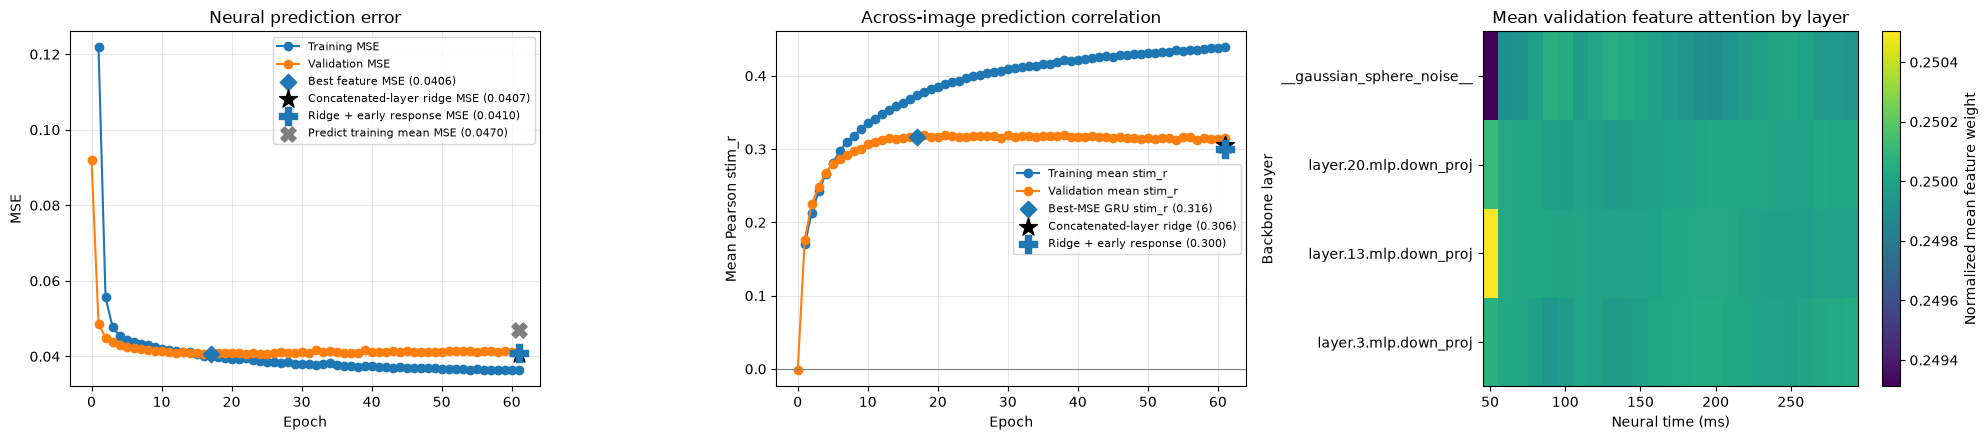

In [13]:
# Average attention over all validation stimuli after training.
m.eval()
validation_attention = []
with torch.no_grad():
    for inputs, early_response, _ in validation_loader:
        _, attention_weights = m(
            inputs.to(m.device),
            early_response.to(m.device),
            use_precomputed_features=use_precomputed_features,
        )
        layer_attention = aggregate_attention_by_layer(
            attention_weights
        )
        validation_attention.append(layer_attention.cpu())
    # end for validation batch
# end with no gradient tracking

mean_layer_attention = torch.cat(validation_attention, dim=0).mean(dim=0)

# Attention is constant inside each fine-time block produced by one coarse query.
mean_fine_attention = mean_layer_attention.repeat_interleave(
    m.get_temporal_compression_ratio(),
    dim=0,
)

# Plot optimization error and the final validation-set attention schedule.
training_epochs = np.arange(1, len(training_losses) + 1)
validation_epochs = np.arange(0, len(validation_losses) + 1)
all_validation_losses = np.asarray(
    [initial_validation_loss, *validation_losses]
)
best_validation_index = int(np.argmin(all_validation_losses))
best_validation_epoch = int(validation_epochs[best_validation_index])
best_validation_loss = float(
    all_validation_losses[best_validation_index]
)
print(
    "feature attention | best validation "
    f"{best_validation_loss:.6f} at epoch {best_validation_epoch:03d}"
)

fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
axes[0].plot(
    training_epochs,
    training_losses,
    marker="o",
    label=f"Training {training_metric_label}",
)
axes[0].plot(
    validation_epochs,
    all_validation_losses,
    marker="o",
    label=f"Validation {validation_metric_label}",
)
axes[0].scatter(
    best_validation_epoch,
    best_validation_loss,
    marker="D",
    s=70,
    zorder=4,
    label=(
        f"Best feature {validation_metric_label} "
        f"({best_validation_loss:.4f})"
    ),
)
axes[0].scatter(
    validation_epochs[-1],
    ridge_validation_mse,
    marker="*",
    s=180,
    color="black",
    zorder=4,
    label=(
        f"Concatenated-layer ridge {validation_metric_label} "
        f"({ridge_validation_mse:.4f})"
    ),
)
axes[0].scatter(
    validation_epochs[-1],
    ridge_early_validation_mse,
    marker="P",
    s=150,
    color="tab:blue",
    zorder=4,
    label=(
        f"Ridge + early response {validation_metric_label} "
        f"({ridge_early_validation_mse:.4f})"
    ),
)
axes[0].scatter(
    validation_epochs[-1],
    mean_validation_mse,
    marker="X",
    s=120,
    color="tab:gray",
    zorder=4,
    label=(
        f"Predict training mean {validation_metric_label} "
        f"({mean_validation_mse:.4f})"
    ),
)
if neural_response_ceiling is not None:
    axes[0].axhspan(
        neural_response_ceiling['percentile_05'],
        neural_response_ceiling['percentile_95'],
        color="tab:purple",
        alpha=0.10,
        label="Neural-response CV 5--95%",
    )
    axes[0].axhline(
        neural_response_ceiling['minimum_mse'],
        color="tab:purple",
        linestyle="--",
        linewidth=2,
        label=(
            "Neural-response ceiling: minimum CV MSE "
            f"({neural_response_ceiling['minimum_mse']:.4f})"
        ),
    )
# end if repeated-raster ceiling diagnostics are available
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel(training_metric_label)
axes[0].set_title("Neural prediction error")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

# Correlation is computed across validation images at each target cell.
all_validation_correlations = np.asarray(
    [initial_validation_correlation, *validation_correlations]
)
axes[1].plot(
    training_epochs,
    training_correlations,
    marker="o",
    label="Training mean stim_r",
)
axes[1].plot(
    validation_epochs,
    all_validation_correlations,
    marker="o",
    label="Validation mean stim_r",
)
axes[1].scatter(
    best_model_epoch,
    best_model_validation_correlation,
    marker="D",
    s=70,
    zorder=4,
    label=(
        f"Best-MSE GRU stim_r "
        f"({best_model_validation_correlation:.3f})"
    ),
)
axes[1].scatter(
    validation_epochs[-1],
    ridge_validation_correlation,
    marker="*",
    s=180,
    color="black",
    zorder=4,
    label=f"Concatenated-layer ridge ({ridge_validation_correlation:.3f})",
)
axes[1].scatter(
    validation_epochs[-1],
    ridge_early_validation_correlation,
    marker="P",
    s=150,
    color="tab:blue",
    zorder=4,
    label=(
        "Ridge + early response "
        f"({ridge_early_validation_correlation:.3f})"
    ),
)
axes[1].axhline(0.0, color="grey", linewidth=0.8)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean Pearson stim_r")
axes[1].set_title("Across-image prediction correlation")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

attention_image = axes[2].imshow(
    mean_fine_attention.T.numpy(),
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="viridis",
)
attention_times_ms = time_axis_ms(
    mean_fine_attention.shape[0], cfg.new_fs, target_time_start_ms
)
attention_tick_indices = np.arange(0, len(attention_times_ms), 5)
axes[2].set_xticks(attention_tick_indices)
axes[2].set_xticklabels(attention_times_ms[attention_tick_indices].astype(int))
axes[2].set_xlabel("Neural time (ms)")
axes[2].set_ylabel("Backbone layer")
axes[2].set_title("Mean validation feature attention by layer")
axes[2].set_yticks(np.arange(len(m.get_layer_names())))
axes[2].set_yticklabels(m.get_layer_names())
fig.colorbar(
    attention_image,
    ax=axes[2],
    label="Normalized mean feature weight",
)
fig.tight_layout()
plt.show()

## Dynamic RSA of the neural, decoded, and recurrent geometries

Every panel below compares representational geometries over image identity,
computed on the held-out validation images only. Repeated presentations of one
image are averaged first, one RDM (`cfg.drsa_rdm_metric`) is built per time bin,
and RDMs are compared with `cfg.drsa_rsa_metric`.

The **autocorrelations** are the time-by-time dRSA of one signal with itself.
They show how quickly a geometry changes: the neural signal drifts away from its
own early geometry, whereas a decoder driven by a single static image can only
produce whatever temporal drift its recurrence generates.

Their diagonals are trivially one, so each panel is scaled by its largest
off-diagonal value instead. That matters because the two kinds of signal live on
completely different scales: model RDMs are noiseless, while a single 10 ms bin
of this population estimates the image geometry very poorly. The split-half
reliability of the neural RDM per bin is printed below and drawn as the ceiling
on the dRSA time course; every neural panel is bounded by it.

The **cross dRSA** matrices put neural time on the vertical axis and model time
on the horizontal axis, so the dashed identity line is the temporally aligned
comparison. Its diagonal is the dRSA time course plotted last, for

- the predicted population before and after fitting (the untrained decoder is
  rebuilt from `cfg.random_seed`, i.e. exactly the weights training started from),
- the GRU hidden state before and after fitting, and
- the concatenated-layer ridge prediction, image-only and with the early bins
  appended, which has no recurrence at all: its geometry can only change over
  time through the fitted per-bin weights.

All time axes cover the predicted window only, i.e. they start after the
`cfg.n_early_bins` observed bins.

In [14]:
# Every dRSA below uses validation images only, in unshuffled loader order.
n_neurons, n_time = raster_array.shape[0], n_target_timepoints
validation_trial_image_indices = full_dataset.image_indices[
    validation_trial_indices
]

# Rebuild the decoder from the training seed to recover the pre-fitting weights.
torch.manual_seed(cfg.random_seed)
untrained_m = EarlyResponseShowAttendTellGRUModel(
    ann,
    layers=cfg.layer_names,
    n_timepoints=n_time,
    n_neurons=n_neurons,
    hidden_dim=cfg.hidden_dim,
    attention_dim=cfg.attention_dim,
    n_early_bins=cfg.n_early_bins,
    early_dim=cfg.early_dim,
    dropout=cfg.dropout,
    early_dropout=cfg.early_dropout,
    use_noise_layer=cfg.use_noise_layer,
    match_noise_norm=cfg.match_noise_norm,
    noise_in_eval=cfg.noise_in_eval,
    use_temporal_embeddings=cfg.use_temporal_embeddings,
    encoder_dim=(
        None
        if precomputed_layer_features is None
        else precomputed_layer_features.shape[-1]
    ),
).to(model_device)

trained_predictions, trained_hidden, validation_targets = (
    collect_gru_time_series(
        m,
        validation_loader,
        use_precomputed_features,
        device=m.device,
    )
)
untrained_predictions, untrained_hidden, _ = collect_gru_time_series(
    untrained_m,
    validation_loader,
    use_precomputed_features,
    device=untrained_m.device,
)

# Ridge was fitted on the same split; its rows follow the same loader order.
ridge_predictions = ridge_validation_predictions.reshape(
    -1, n_time, n_neurons
)
ridge_early_predictions = ridge_early_validation_predictions.reshape(
    -1, n_time, n_neurons
)

# Average repetitions, then prepare one RDM time series per signal so that
# every dRSA panel is a single matrix product between prepared RDMs.
drsa_signals = {
    "neural": validation_targets,
    "population before fit": untrained_predictions,
    "population after fit": best_model_predictions,
    "hidden before fit": untrained_hidden,
    "hidden after fit": trained_hidden,
    "ridge": ridge_predictions,
    "ridge + early response": ridge_early_predictions,
}
drsa_image_indices = np.unique(validation_trial_image_indices)
prepared_rdms = {}
for signal_name, trial_values in drsa_signals.items():
    if signal_name == "population after fit":
        # These predictions were retained at the best validation epoch.
        if cfg.neural_data_source == "raster":
            image_values = trial_values
        else:
            # Match the sorted image-ID order used by the other signals.
            image_values = trial_values[
                np.argsort(validation_trial_image_indices)
            ]
        # end if best predictions were already image-aggregated
    else:
        image_values, _ = average_time_series_by_image(
            trial_values,
            validation_trial_image_indices,
        )
    # end if predictions are already averaged by image
    prepared_rdms[signal_name] = prepared_rdm_time_series(
        image_values,
        rdm_metric=cfg.drsa_rdm_metric,
        rsa_metric=cfg.drsa_rsa_metric,
    )
# end for signal entering the dynamic RSA

drsa_times_ms = time_axis_ms(n_time, cfg.new_fs, target_time_start_ms)

# The neural RDM ceiling needs repeated responses and is optional for Paul.
neural_rdm_reliability = None
neural_rdm_ceiling = None
if cfg.use_reliability_weighted_loss:
    validation_repetition_mask = np.isin(
        self_consistency_image_indices, drsa_image_indices
    )
    repeated_validation_images, repeated_validation_counts = np.unique(
        self_consistency_image_indices[validation_repetition_mask],
        return_counts=True,
    )
    validation_repetition_mask &= np.isin(
        self_consistency_image_indices,
        repeated_validation_images[repeated_validation_counts >= 2],
    )
    neural_rdm_reliability = rdm_split_half_reliability(
        self_consistency_trial_targets[validation_repetition_mask],
        self_consistency_image_indices[validation_repetition_mask],
        rdm_metric=cfg.drsa_rdm_metric,
        rsa_metric=cfg.drsa_rsa_metric,
        n_resamples=cfg.drsa_reliability_resamples,
        seed=cfg.random_seed,
    )
    neural_rdm_ceiling = np.sqrt(neural_rdm_reliability)
# end if repeated responses are available for an RDM ceiling

print(
    f"dRSA over {len(drsa_image_indices)} validation images | "
    f"{n_time} bins {drsa_times_ms[0]:.0f}-{drsa_times_ms[-1]:.0f} ms | "
    f"RDM {cfg.drsa_rdm_metric} | RSA {cfg.drsa_rsa_metric}"
)
if neural_rdm_reliability is not None:
    print(
        "neural RDM split-half reliability | peak "
        f"{neural_rdm_reliability.max():.3f} at "
        f"{drsa_times_ms[int(np.argmax(neural_rdm_reliability))]:.0f} ms | "
        f"mean {neural_rdm_reliability.mean():.3f} | "
        f"ceiling on dRSA (sqrt) peak {neural_rdm_ceiling.max():.3f}"
    )
else:
    print("neural RDM split-half reliability: unavailable")
# end if the neural RDM ceiling was estimated

dRSA over 875 validation images | 25 bins 50-290 ms | RDM euclidean | RSA spearman
neural RDM split-half reliability: unavailable


Neural signal                      | max off-diagonal autocorrelation 0.501
Predicted population (after fit)   | max off-diagonal autocorrelation 0.999
Predicted population (before fit)  | max off-diagonal autocorrelation 1.000
GRU hidden state (after fit)       | max off-diagonal autocorrelation 0.999


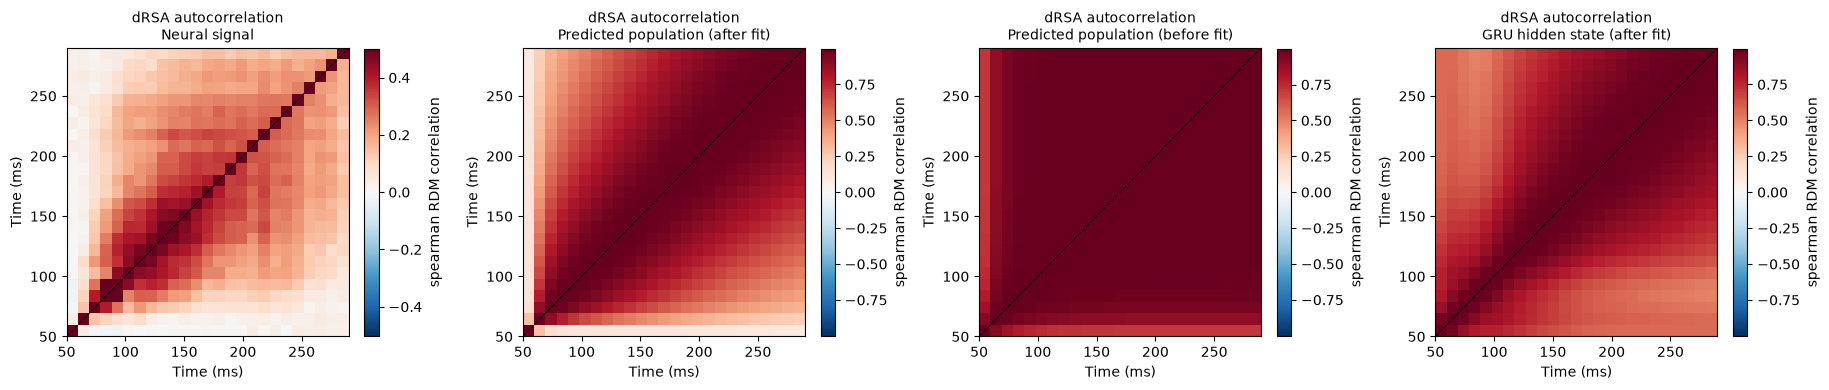

In [15]:
# Autocorrelation: how fast each geometry moves away from its own past.
autocorrelation_names = [
    ("neural", "Neural signal"),
    ("population after fit", "Predicted population (after fit)"),
    ("population before fit", "Predicted population (before fit)"),
    ("hidden after fit", "GRU hidden state (after fit)"),
]
autocorrelations = {
    name: drsa_from_prepared(prepared_rdms[name], prepared_rdms[name])
    for name, _ in autocorrelation_names
}

# The unit diagonal is trivial, and the noisy neural RDMs and the noiseless
# model RDMs differ by an order of magnitude, so each panel is scaled by its
# own largest off-diagonal value and carries its own colorbar.
fig, axes = plt.subplots(
    1,
    len(autocorrelation_names),
    figsize=(4.6 * len(autocorrelation_names), 4.0),
)
for ax, (name, title) in zip(axes, autocorrelation_names):
    panel_limit = off_diagonal_limit(autocorrelations[name])
    autocorrelation_image = plot_drsa_matrix(
        ax,
        autocorrelations[name],
        drsa_times_ms,
        drsa_times_ms,
        f"dRSA autocorrelation\n{title}",
        row_label="Time (ms)",
        column_label="Time (ms)",
        vmin=-panel_limit,
        vmax=panel_limit,
    )
    fig.colorbar(
        autocorrelation_image,
        ax=ax,
        fraction=0.046,
        label=f"{cfg.drsa_rsa_metric} RDM correlation",
    )
    print(f"{title:34s} | max off-diagonal autocorrelation {panel_limit:.3f}")
# end for autocorrelation panel
fig.tight_layout()
plt.show()

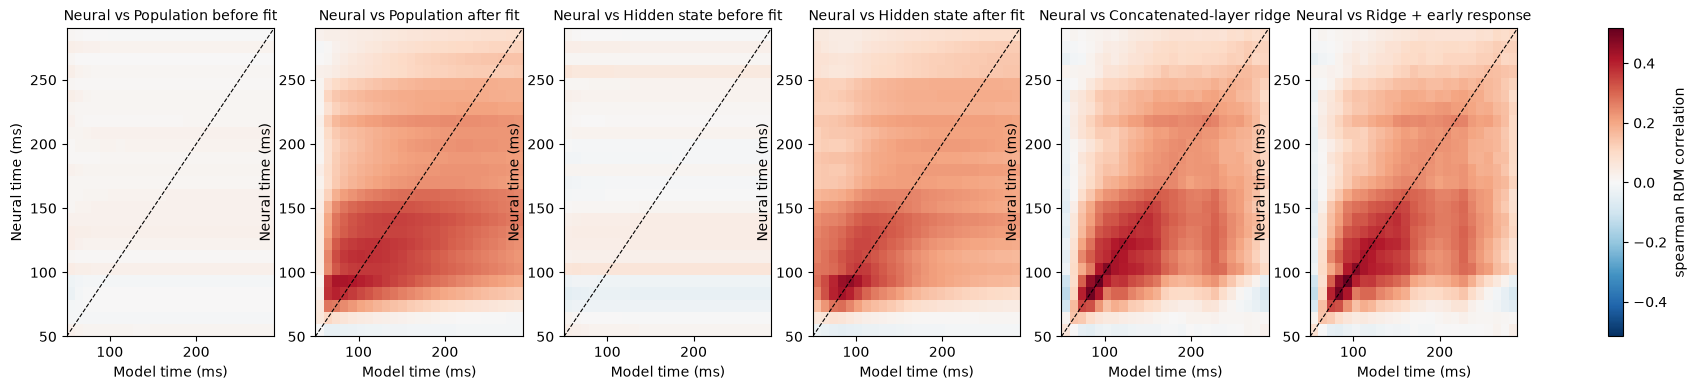

Population before fit      | peak aligned dRSA 0.027 at 130 ms | mean 0.011
Population after fit       | peak aligned dRSA 0.414 at 90 ms | mean 0.242
Hidden state before fit    | peak aligned dRSA 0.061 at 100 ms | mean 0.013
Hidden state after fit     | peak aligned dRSA 0.457 at 90 ms | mean 0.231
Concatenated-layer ridge   | peak aligned dRSA 0.517 at 90 ms | mean 0.277
Ridge + early response     | peak aligned dRSA 0.514 at 90 ms | mean 0.276


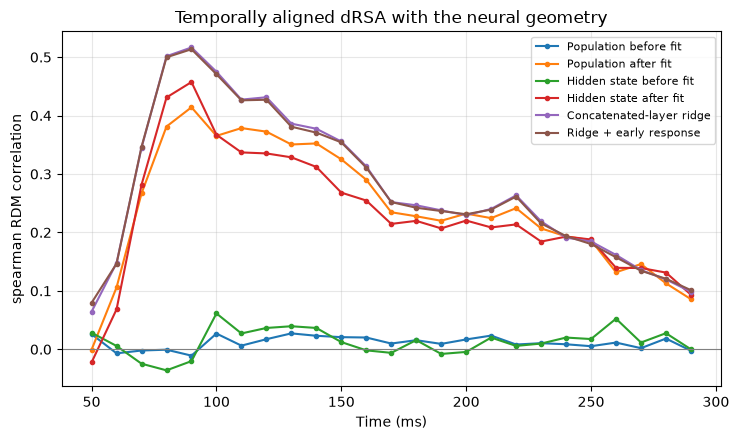

In [16]:
# Cross dRSA: neural time (rows) against model time (columns).
cross_names = [
    ("population before fit", "Population before fit"),
    ("population after fit", "Population after fit"),
    ("hidden before fit", "Hidden state before fit"),
    ("hidden after fit", "Hidden state after fit"),
    ("ridge", "Concatenated-layer ridge"),
    ("ridge + early response", "Ridge + early response"),
]
cross_drsa = {
    name: drsa_from_prepared(prepared_rdms["neural"], prepared_rdms[name])
    for name, _ in cross_names
}
cross_limit = float(
    np.nanmax([np.abs(matrix) for matrix in cross_drsa.values()])
)

fig, axes = plt.subplots(
    1,
    len(cross_names),
    figsize=(3.9 * len(cross_names), 4.0),
)
for ax, (name, title) in zip(axes, cross_names):
    cross_image = plot_drsa_matrix(
        ax,
        cross_drsa[name],
        drsa_times_ms,
        drsa_times_ms,
        f"Neural vs {title}",
        vmin=-cross_limit,
        vmax=cross_limit,
    )
# end for cross dRSA panel
fig.colorbar(
    cross_image,
    ax=axes,
    label=f"{cfg.drsa_rsa_metric} RDM correlation",
)
plt.show()

# The diagonal of each matrix is the temporally aligned dRSA time course.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
# Plot the repeated-response ceiling only when it can be estimated.
if neural_rdm_ceiling is not None:
    ax.plot(
        drsa_times_ms,
        neural_rdm_ceiling,
        color="black",
        linestyle=":",
        label="Neural RDM reliability ceiling",
    )
# end if repeated-response dRSA ceiling is available
for name, title in cross_names:
    aligned_drsa = np.diagonal(cross_drsa[name])
    peak_index = int(np.nanargmax(aligned_drsa))
    ax.plot(drsa_times_ms, aligned_drsa, marker="o", markersize=3, label=title)
    print(
        f"{title:26s} | peak aligned dRSA {aligned_drsa[peak_index]:.3f} "
        f"at {drsa_times_ms[peak_index]:.0f} ms | "
        f"mean {np.nanmean(aligned_drsa):.3f}"
    )
# end for dRSA time course
ax.axhline(0.0, color="grey", linewidth=0.8)
ax.set_xlabel("Time (ms)")
ax.set_ylabel(f"{cfg.drsa_rsa_metric} RDM correlation")
ax.set_title("Temporally aligned dRSA with the neural geometry")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()